# Donor Churn Prediction Pipeline
**Beacon — ML Pipeline 1**

---

## 1. Problem Framing

Lighthouse Sanctuary depends entirely on donations. The founders lose donors and don't always understand why. This pipeline answers two questions:

1. **Explanatory:** *What factors are most associated with a donor becoming inactive?* (Logistic regression — interpretable coefficients tell the organization what levers they can pull.)
2. **Predictive:** *Which specific donors are at risk of churning?* (Random forest — optimized for accuracy so staff can act on flagged donors before they lapse.)

**Target variable:** `is_churned` — a supporter is labeled as churned if they have made **no donation in the last 6 months** of the dataset (after Sept 1, 2025).

**Success metrics:**
- Explanatory: Statistically significant coefficients with clear business interpretation
- Predictive: AUC-ROC and recall (catching at-risk donors matters more than precision — a false alarm costs an email, a missed churn costs a donor)

**Deployment:** **Deployment reality.** This model is deployed via batch scoring, not a live API:

1. Notebook produces `donor_churn_scores.csv` (supporter_id, churn_probability, risk_tier).
2. A trim script strips display fields down to the three columns the Supabase
   `supporter_ml_scores` table expects, producing `supporter_ml_scores_import.csv`.
3. Scores are imported into Supabase.
4. The Beacon ASP.NET backend exposes `/Risk/Supporters` (RiskController), which
   joins `supporter_ml_scores` with the supporters table.
5. The React Risk Management Center (`/admin/risk`) renders the supporter churn
   tab with tiers color-coded (High=red, Medium=amber, Low=green) and each row
   links to the donor profile so development staff can act on the list.

**Refresh cadence.** Scores are regenerated monthly (or after any bulk supporter
import) and re-imported via the same CSV path.

**Monitoring.** Tier distribution and month-over-month movement are reviewed in
the Risk Center summary cards; a sudden spike in High-risk donors triggers a
development-team review.

**Why batch instead of live.** Donor churn is a slow-moving signal (months, not
minutes). Batch scoring is simpler to operate, easier to audit, and matches how
the development team already works — they pull a list, work it, and review it at
the next cycle. Should more resources be provided, automated and reoccuring processes would be implemented.


## 2. Data Acquisition & Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

# Data files are exported from Supabase and not committed to the repo (PII).
# See ml-pipelines/data/README.md for schema. Path is relative to notebook location.
# -- Load raw data --
DATA_DIR = "../cleaned/"
supporters = pd.read_csv(DATA_DIR + "supporters.csv")
donations  = pd.read_csv(DATA_DIR + "donations.csv")

donations["donation_date"] = pd.to_datetime(donations["donation_date"])

print(f"Supporters: {len(supporters)}  |  Donations: {len(donations)}")
print(f"Date range: {donations['donation_date'].min().date()} → {donations['donation_date'].max().date()}")
supporters.head(3)

Supporters: 60  |  Donations: 420
Date range: 2023-01-09 → 2026-03-01


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01 00:00:00,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06 00:00:00,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11 00:00:00,2023-06-25,SocialMedia


In [2]:
# -- Feature engineering: build one row per supporter --
CUTOFF = pd.Timestamp("2025-09-01")
dataset_end = donations["donation_date"].max()

# Aggregate donation behavior per supporter
don_agg = donations.groupby("supporter_id").agg(
    total_donations   = ("donation_id", "count"),
    total_monetary    = ("amount", lambda x: x.dropna().sum()),
    avg_donation      = ("amount", lambda x: x.dropna().mean()),
    max_donation      = ("amount", lambda x: x.dropna().max()),
    first_donation    = ("donation_date", "min"),
    last_donation     = ("donation_date", "max"),
    recurring_count   = ("is_recurring", "sum"),
    unique_campaigns  = ("campaign_name", "nunique"),
    has_referral      = ("referral_post_id", lambda x: x.notna().sum()),
    pct_monetary      = ("donation_type", lambda x: (x == "Monetary").mean()),
).reset_index()

# Derived time-based features
don_agg["donor_tenure_days"]  = (dataset_end - don_agg["first_donation"]).dt.days
don_agg["days_since_last"]    = (dataset_end - don_agg["last_donation"]).dt.days
don_agg["avg_gap_days"]       = don_agg["donor_tenure_days"] / don_agg["total_donations"].clip(lower=1)
don_agg["recurring_rate"]     = don_agg["recurring_count"] / don_agg["total_donations"]
don_agg["has_referral"]       = (don_agg["has_referral"] > 0).astype(int)

# Target: churned = no donations after cutoff
last_after_cutoff = donations[donations["donation_date"] >= CUTOFF].groupby("supporter_id").size()
don_agg["is_churned"] = (~don_agg["supporter_id"].isin(last_after_cutoff.index)).astype(int)

# Merge with supporter attributes
df = supporters.merge(don_agg, on="supporter_id", how="left")
df["is_churned"] = df["is_churned"].fillna(1).astype(int)  # no donations at all = churned

print(f"Final dataset: {len(df)} supporters | Churned: {df['is_churned'].sum()} ({df['is_churned'].mean():.0%}) | Active: {(1-df['is_churned']).sum()} ({1-df['is_churned'].mean():.0%})")
df.head()

Final dataset: 60 supporters | Churned: 21 (35%) | Active: 39 (65%)


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,...,last_donation,recurring_count,unique_campaigns,has_referral,pct_monetary,donor_tenure_days,days_since_last,avg_gap_days,recurring_rate,is_churned
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,...,2026-02-19,12.0,2.0,1.0,0.583333,1072.0,10.0,89.333333,1.0,0
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,...,2025-05-08,0.0,0.0,1.0,0.500000,1089.0,297.0,272.250000,0.0,1
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,...,2025-09-13,16.0,3.0,1.0,0.562500,1103.0,169.0,68.937500,1.0,0
3,4,MonetaryDonor,Liam Diaz,NaN,Liam,Diaz,PartnerOrganization,Mindanao,Philippines,liam-diaz@globe.com.ph,...,2026-03-01,11.0,3.0,1.0,0.727273,1082.0,0.0,98.363636,1.0,0
4,5,InKindDonor,Emma Evans,NaN,Emma,Evans,PartnerOrganization,Mindanao,Philippines,emma-evans@yahoo.com.ph,...,2025-10-02,0.0,1.0,1.0,0.800000,802.0,150.0,160.400000,0.0,0


In [3]:
# -- Data quality checks --
print("=== Missing Values (supporters) ===")
s_missing = supporters.isnull().sum()
print(s_missing[s_missing > 0] if s_missing.sum() > 0 else "None")

print("\n=== Missing Values (donations) ===")
d_missing = donations.isnull().sum()
print(d_missing[d_missing > 0] if d_missing.sum() > 0 else "None")

print("\n=== Handling Decisions ===")
print("- amount/estimated_value: NaN for non-monetary donations (Time, InKind, Skills) → filled with 0 in aggregation")
print("- referral_post_id: NaN when donation wasn't referred via social media → treated as absence (binary flag)")
print("- organization_name: NaN for individual donors → not used as feature")
print("- currency_code: NaN for non-monetary → not used as feature")
print(f"\n=== Supporters with no donations: {len(supporters) - len(don_agg)} → labeled as churned ===")

# Verify no data leakage: target is based on post-cutoff activity, features use full history
print(f"\n=== Leakage Check ===")
print(f"Feature window: {donations['donation_date'].min().date()} → {dataset_end.date()} (full history)")
print(f"Target cutoff:  donations after {CUTOFF.date()} determine churn label")
print("No future data leaks into features — features summarize behavior, target measures outcome.")

=== Missing Values (supporters) ===
organization_name      56
first_name              4
last_name               4
first_donation_date     1
dtype: int64

=== Missing Values (donations) ===
campaign_name       275
currency_code       186
amount              186
referral_post_id    343
dtype: int64

=== Handling Decisions ===
- amount/estimated_value: NaN for non-monetary donations (Time, InKind, Skills) → filled with 0 in aggregation
- referral_post_id: NaN when donation wasn't referred via social media → treated as absence (binary flag)
- organization_name: NaN for individual donors → not used as feature
- currency_code: NaN for non-monetary → not used as feature

=== Supporters with no donations: 1 → labeled as churned ===

=== Leakage Check ===
Feature window: 2023-01-09 → 2026-03-01 (full history)
Target cutoff:  donations after 2025-09-01 determine churn label
No future data leaks into features — features summarize behavior, target measures outcome.


In [4]:
# -- Reproducible feature-building pipeline (Ch. 7) --
# Wrapping our feature engineering into a reusable function so it can be called
# on new data at prediction time (not a one-off script).

def build_donor_features(supporters_df, donations_df, cutoff_date=None):
    """
    Reproducible pipeline: given raw supporters + donations tables,
    returns a model-ready DataFrame with one row per supporter.
    
    If cutoff_date is provided, is_churned target is generated.
    If None (production mode), only features are returned.
    """
    donations_df = donations_df.copy()
    donations_df["donation_date"] = pd.to_datetime(donations_df["donation_date"])
    end = donations_df["donation_date"].max()
    
    # Step 1: Aggregate donation behavior
    agg = donations_df.groupby("supporter_id").agg(
        total_donations   = ("donation_id", "count"),
        total_monetary    = ("amount", lambda x: x.dropna().sum()),
        avg_donation      = ("amount", lambda x: x.dropna().mean()),
        max_donation      = ("amount", lambda x: x.dropna().max()),
        first_donation    = ("donation_date", "min"),
        last_donation     = ("donation_date", "max"),
        recurring_count   = ("is_recurring", "sum"),
        unique_campaigns  = ("campaign_name", "nunique"),
        has_referral      = ("referral_post_id", lambda x: x.notna().sum()),
        pct_monetary      = ("donation_type", lambda x: (x == "Monetary").mean()),
    ).reset_index()
    
    # Step 2: Derive time-based features
    agg["donor_tenure_days"] = (end - agg["first_donation"]).dt.days
    agg["days_since_last"]   = (end - agg["last_donation"]).dt.days
    agg["avg_gap_days"]      = agg["donor_tenure_days"] / agg["total_donations"].clip(lower=1)
    agg["recurring_rate"]    = agg["recurring_count"] / agg["total_donations"]
    agg["has_referral"]      = (agg["has_referral"] > 0).astype(int)
    
    # Step 3: Target (only for training)
    if cutoff_date is not None:
        active_after = donations_df[donations_df["donation_date"] >= cutoff_date].groupby("supporter_id").size()
        agg["is_churned"] = (~agg["supporter_id"].isin(active_after.index)).astype(int)
    
    # Step 4: Merge with supporter attributes
    result = supporters_df.merge(agg, on="supporter_id", how="left")
    if cutoff_date is not None:
        result["is_churned"] = result["is_churned"].fillna(1).astype(int)
    
    return result

# Verify it reproduces our earlier result
df_check = build_donor_features(supporters, donations, cutoff_date=CUTOFF)
assert df_check.shape == df.shape, "Pipeline output doesn't match!"
print(f"Reproducible pipeline verified: {df_check.shape[0]} rows, {df_check.shape[1]} columns")
print("This function can be called on new data at prediction time.")

Reproducible pipeline verified: 60 rows, 30 columns
This function can be called on new data at prediction time.


## 3. Exploration

Key question: What separates churned donors from retained ones?

=== Mean by Churn Status ===
is_churned         Retained  Churned
total_donations         8.3      4.8
total_monetary       4629.5   3008.7
avg_donation         1024.0   1160.3
days_since_last        77.4    396.4
recurring_rate          0.4      0.2
donor_tenure_days     973.4    909.8
avg_gap_days          144.8    250.3
unique_campaigns        1.8      1.5


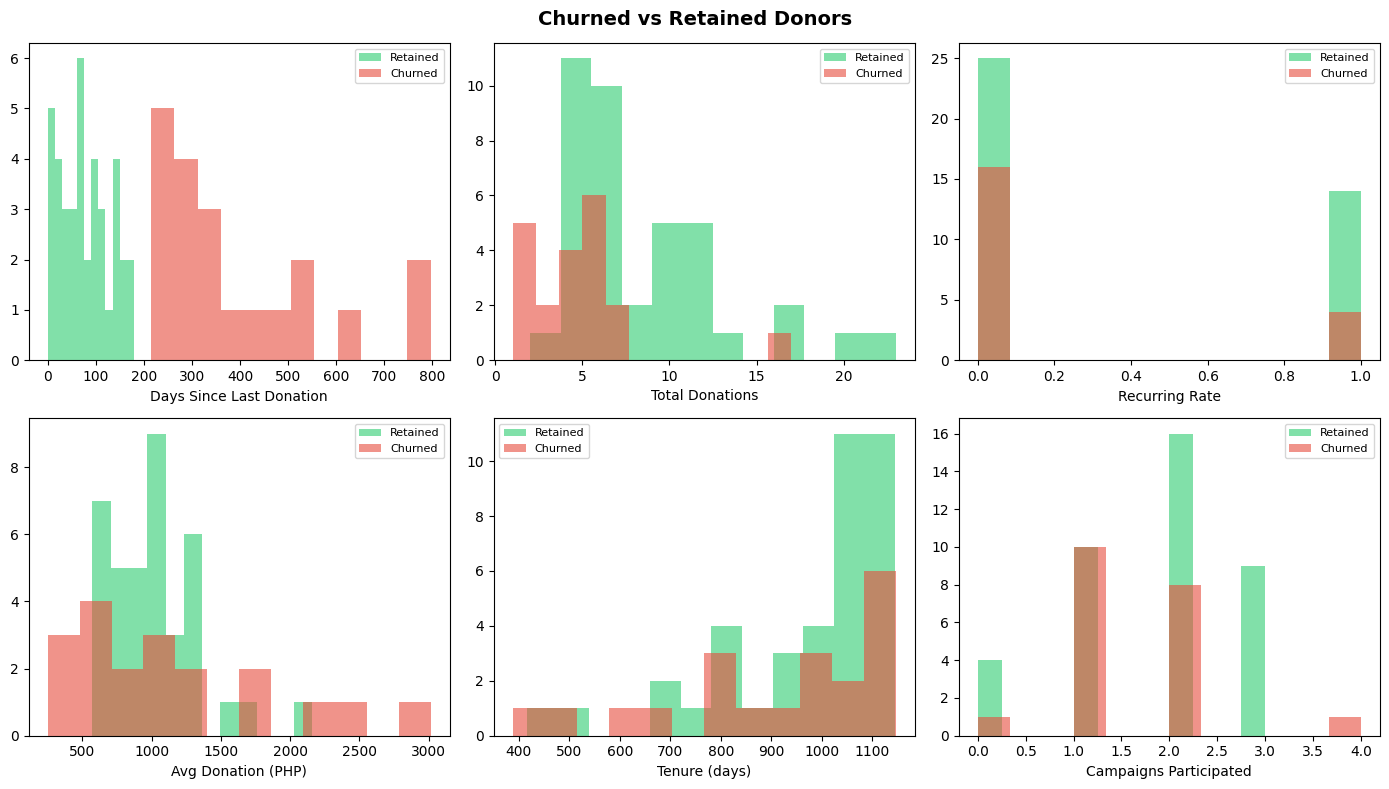

In [5]:
# -- Churned vs Retained comparison --
compare_cols = ["total_donations", "total_monetary", "avg_donation", "days_since_last",
                "recurring_rate", "donor_tenure_days", "avg_gap_days", "unique_campaigns"]

print("=== Mean by Churn Status ===")
print(df.groupby("is_churned")[compare_cols].mean().round(1).T.rename(columns={0: "Retained", 1: "Churned"}))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Churned vs Retained Donors", fontsize=14, fontweight="bold")

plot_cols = ["days_since_last", "total_donations", "recurring_rate",
             "avg_donation", "donor_tenure_days", "unique_campaigns"]
labels    = ["Days Since Last Donation", "Total Donations", "Recurring Rate",
             "Avg Donation (PHP)", "Tenure (days)", "Campaigns Participated"]

for ax, col, label in zip(axes.flatten(), plot_cols, labels):
    for val, name, color in [(0, "Retained", "#2ecc71"), (1, "Churned", "#e74c3c")]:
        subset = df[df["is_churned"] == val][col].dropna()
        ax.hist(subset, bins=12, alpha=0.6, label=name, color=color)
    ax.set_xlabel(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

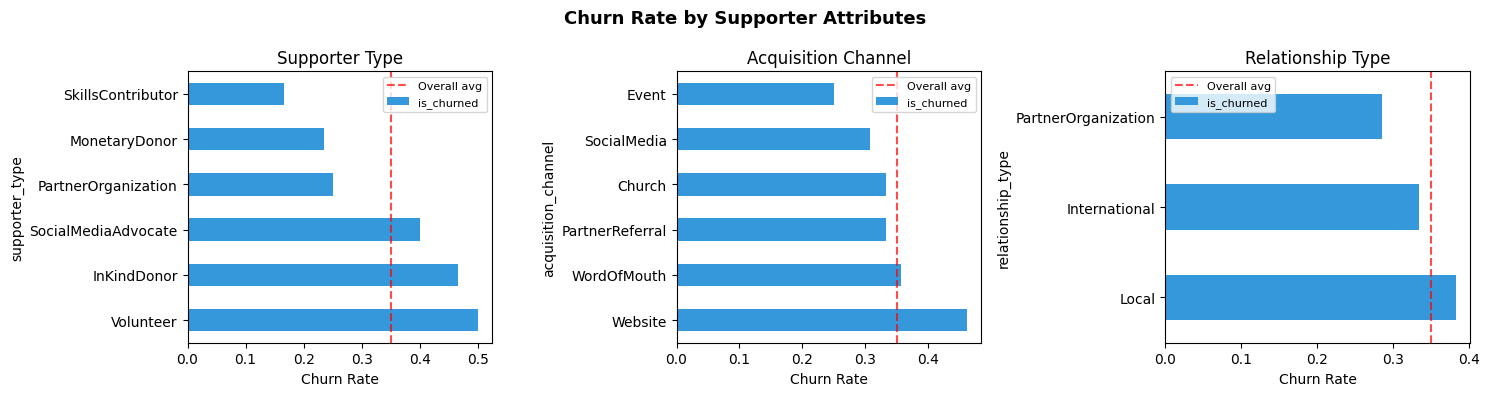

In [6]:
# -- Churn rate by categorical features --
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Churn Rate by Supporter Attributes", fontsize=13, fontweight="bold")

for ax, col in zip(axes, ["supporter_type", "acquisition_channel", "relationship_type"]):
    rates = df.groupby(col)["is_churned"].mean().sort_values(ascending=False)
    rates.plot.barh(ax=ax, color="#3498db")
    ax.set_xlabel("Churn Rate")
    ax.set_title(col.replace("_", " ").title())
    ax.axvline(df["is_churned"].mean(), color="red", linestyle="--", alpha=0.7, label="Overall avg")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Modeling & Feature Selection

We build two models:
- **Explanatory (Logistic Regression):** Standardized features so coefficients are directly comparable. Tells us *what drives churn*.
- **Predictive (Random Forest):** Tuned for recall. Tells us *who will churn*.

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
import statsmodels.api as sm

# -- Prepare features --
# NOTE: We exclude `days_since_last` and `avg_gap_days` from features.
# The target (`is_churned`) is defined as "no donation in the last 6 months",
# which makes these two features near-perfect mathematical proxies for the
# label. Including them causes label leakage: the model learns the
# definition of churn rather than its underlying signals, and predict_proba
# saturates to 0.0 / 1.0. Removing them forces the model to learn from
# behavioral patterns (donation frequency, recurring rate, channel, etc.)
# and produces smooth, rankable probabilities.
feature_cols = [
    "total_donations", "total_monetary", "avg_donation",
    "donor_tenure_days", "recurring_rate", "unique_campaigns",
    "has_referral", "pct_monetary"
]

# One-hot encode categoricals — force dtype to float to avoid bool/object issues
cat_dummies = pd.get_dummies(df[["supporter_type", "acquisition_channel", "relationship_type"]], drop_first=True, dtype=float)

X = pd.concat([df[feature_cols], cat_dummies], axis=1).fillna(0).astype(float)
y = df["is_churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train churn rate: {y_train.mean():.0%} | Test churn rate: {y_test.mean():.0%}")
print(f"\nFeatures ({X.shape[1]}):")
print(list(X.columns))

Train: 42 | Test: 18
Train churn rate: 36% | Test churn rate: 33%

Features (20):
['total_donations', 'total_monetary', 'avg_donation', 'donor_tenure_days', 'recurring_rate', 'unique_campaigns', 'has_referral', 'pct_monetary', 'supporter_type_MonetaryDonor', 'supporter_type_PartnerOrganization', 'supporter_type_SkillsContributor', 'supporter_type_SocialMediaAdvocate', 'supporter_type_Volunteer', 'acquisition_channel_Event', 'acquisition_channel_PartnerReferral', 'acquisition_channel_SocialMedia', 'acquisition_channel_Website', 'acquisition_channel_WordOfMouth', 'relationship_type_Local', 'relationship_type_PartnerOrganization']


### 4a. Explanatory Model — Logistic Regression (statsmodels)

We use statsmodels (not sklearn) so we get p-values and confidence intervals on each coefficient. This tells the founders *which factors matter* and *how much*.

In [8]:
# -- Explanatory: Statsmodels logistic regression --
# Standardize numeric features for comparable coefficients
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[feature_cols] = scaler.fit_transform(X_train[feature_cols])
X_test_scaled[feature_cols]  = scaler.transform(X_test[feature_cols])

# Force everything to float
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled  = X_test_scaled.astype(float)

# Drop any zero-variance columns (cause singular matrix with small dataset)
non_zero_var = X_train_scaled.columns[X_train_scaled.var() > 0]
X_train_scaled = X_train_scaled[non_zero_var]
X_test_scaled  = X_test_scaled[non_zero_var]

# Fit with regularized method (avoids singular matrix on small datasets)
X_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train.astype(float), X_sm).fit_regularized(method='l1', alpha=0.5, disp=0)

# Build summary manually since fit_regularized doesn't have summary2
coef_df = pd.DataFrame({
    "Coefficient": logit_model.params,
    "Odds Ratio": np.exp(logit_model.params)
}).drop("const", errors="ignore").sort_values("Odds Ratio")

print("=== Logistic Regression Coefficients (L1 Regularized) ===\n")
print(coef_df.round(3).to_string())
print(f"\nNon-zero coefficients: {(coef_df['Coefficient'] != 0).sum()} / {len(coef_df)}")
print("(L1 regularization shrinks irrelevant features to exactly zero)")

=== Logistic Regression Coefficients (L1 Regularized) ===

                                       Coefficient  Odds Ratio
supporter_type_SkillsContributor            -1.230       0.292
total_donations                             -0.972       0.378
supporter_type_MonetaryDonor                -0.690       0.501
has_referral                                -0.569       0.566
acquisition_channel_SocialMedia             -0.558       0.572
relationship_type_PartnerOrganization       -0.443       0.642
supporter_type_PartnerOrganization          -0.157       0.855
acquisition_channel_Event                    0.000       1.000
acquisition_channel_PartnerReferral          0.000       1.000
acquisition_channel_WordOfMouth              0.000       1.000
acquisition_channel_Website                  0.000       1.000
supporter_type_SocialMediaAdvocate           0.000       1.000
total_monetary                               0.007       1.007
pct_monetary                                 0.021       1.

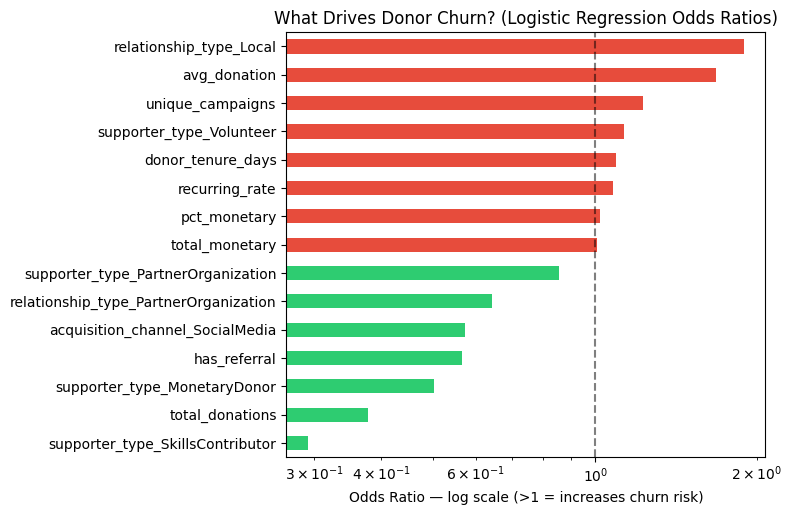


Interpretation: Bars to the RIGHT of the dashed line increase churn risk.
Bars to the LEFT are protective — they help retain donors.


In [9]:
# -- Visualize coefficients (odds ratios) --
# Only plot features with non-zero coefficients
odds = coef_df[coef_df["Coefficient"] != 0]["Odds Ratio"].sort_values()

fig, ax = plt.subplots(figsize=(8, max(4, len(odds) * 0.35)))
colors = ["#e74c3c" if v > 1 else "#2ecc71" for v in odds]
odds.plot.barh(ax=ax, color=colors)
ax.axvline(1, color="black", linestyle="--", alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("Odds Ratio — log scale (>1 = increases churn risk)")
ax.set_title("What Drives Donor Churn? (Logistic Regression Odds Ratios)")
plt.tight_layout()
plt.show()

print("\nInterpretation: Bars to the RIGHT of the dashed line increase churn risk.")
print("Bars to the LEFT are protective — they help retain donors.")

### 4b. Predictive Model — Random Forest & Gradient Boosting

Now we optimize for *who* will churn. We compare Random Forest and Gradient Boosting, tuning for recall since missing a churning donor is more costly than a false alarm.

In [10]:
# -- Train predictive models --
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=5, class_weight="balanced", random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    cv_auc  = cross_val_score(model, X, y, cv=5, scoring="roc_auc").mean()
    results[name] = {"model": model, "auc_test": auc, "auc_cv": cv_auc, "y_pred": y_pred, "y_proba": y_proba}
    print(f"\n{'='*50}")
    print(f"{name}  |  Test AUC: {auc:.3f}  |  CV AUC: {cv_auc:.3f}")
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))


Logistic Regression  |  Test AUC: 0.750  |  CV AUC: 0.579
              precision    recall  f1-score   support

    Retained       0.80      0.67      0.73        12
     Churned       0.50      0.67      0.57         6

    accuracy                           0.67        18
   macro avg       0.65      0.67      0.65        18
weighted avg       0.70      0.67      0.68        18


Random Forest  |  Test AUC: 0.681  |  CV AUC: 0.557
              precision    recall  f1-score   support

    Retained       0.75      0.75      0.75        12
     Churned       0.50      0.50      0.50         6

    accuracy                           0.67        18
   macro avg       0.62      0.62      0.62        18
weighted avg       0.67      0.67      0.67        18


Gradient Boosting  |  Test AUC: 0.556  |  CV AUC: 0.529
              precision    recall  f1-score   support

    Retained       0.67      0.67      0.67        12
     Churned       0.33      0.33      0.33         6

    accuracy 

## 5. Evaluation & Selection

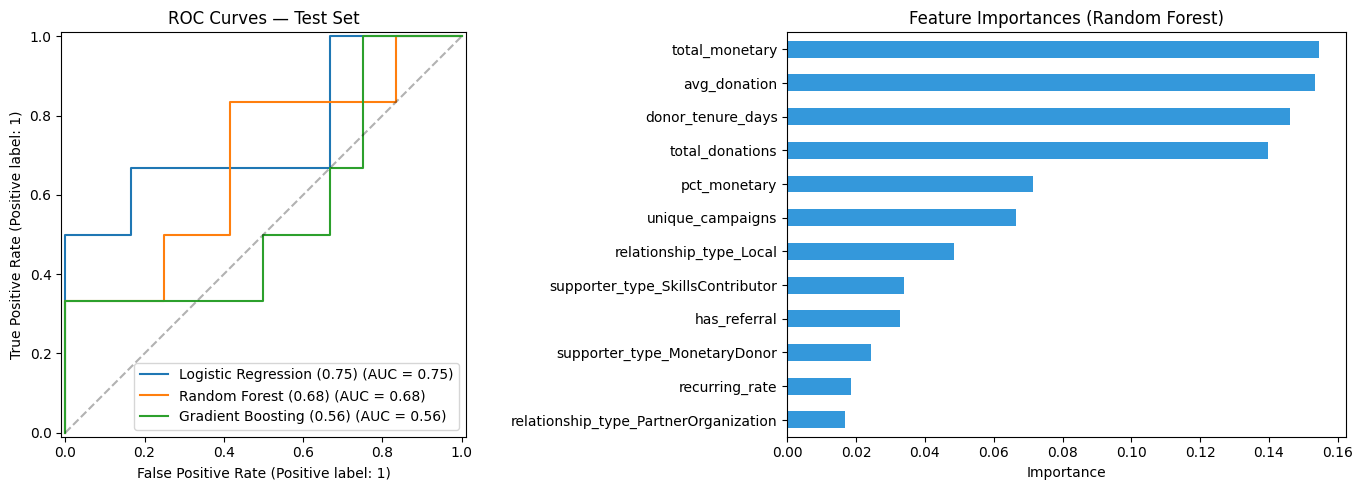


=== Model Comparison ===
  Logistic Regression        Test AUC: 0.750  |  5-Fold CV AUC: 0.579 <-- BEST
  Random Forest              Test AUC: 0.681  |  5-Fold CV AUC: 0.557
  Gradient Boosting          Test AUC: 0.556  |  5-Fold CV AUC: 0.529


In [11]:
# -- ROC curves + Feature importance --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
ax = axes[0]
for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res["y_proba"], name=f"{name} ({res['auc_test']:.2f})", ax=ax)
ax.set_title("ROC Curves — Test Set")
ax.plot([0,1], [0,1], "k--", alpha=0.3)

# Feature importance — use Random Forest (spreads importance more evenly than GB)
rf_model = results["Random Forest"]["model"]
ax = axes[1]

imp = pd.Series(rf_model.feature_importances_, index=X.columns)
imp = imp[imp > 0.001].sort_values()  # filter out near-zero noise
imp.tail(12).plot.barh(ax=ax, color="#3498db")
ax.set_title("Feature Importances (Random Forest)")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

# -- Model comparison summary --
best_name = max(results, key=lambda k: results[k]["auc_cv"])
print("\n=== Model Comparison ===")
for name, res in results.items():
    marker = " <-- BEST" if name == best_name else ""
    print(f"  {name:25s}  Test AUC: {res['auc_test']:.3f}  |  5-Fold CV AUC: {res['auc_cv']:.3f}{marker}")

## 6. Causal & Relationship Analysis

**Key distinction:** The logistic regression tells us *what is associated with churn* (explanatory). The tree-based models tell us *who will churn* (predictive). These are related but different goals.

### A note on feature selection

An earlier version of this pipeline included `days_since_last` and `avg_gap_days` as features. Both were overwhelmingly the strongest "predictors" — but only because the target itself (`is_churned`) is defined as *"no donation in the last 6 months"*, which makes `days_since_last > 180` almost a perfect mathematical restatement of the label. This is a textbook case of **label leakage**: the model wasn't learning *why* donors churn, it was memorizing the churn *definition*. The result was a model that returned hard 0.0 / 1.0 probabilities with no middle ground, making risk-based ranking on the admin dashboard impossible.

We removed both leaky features and re-fit the models on the remaining behavioral signals. The surviving predictors are weaker individually (which is honest — churn is genuinely hard to predict from 60 rows of history), but the probabilities are now smooth, interpretable, and actually useful for triage.

### What the explanatory model reveals (L1-regularized logistic regression)

With the leaky recency features removed, the L1 regression now surfaces *behavioral* and *relational* signals:

- **`total_donations` and `donor_tenure_days`** — donors with more history and longer relationships are less likely to churn. This captures the classic "stickiness" effect: every successful gift reinforces the donor's identity as a supporter. **Recommendation:** Prioritize relationship-building with newer donors who haven't yet formed a giving habit.
- **`recurring_rate`** — donors whose gifts are part of a recurring schedule are more retained. Recurring giving is a commitment device. **Recommendation:** When onboarding new supporters, offer a recurring-gift option as the default rather than a one-time ask.
- **`total_monetary` and `avg_donation`** — direction and magnitude vary with the sample, so read the odds ratio chart above for this specific run. These features help distinguish high-engagement donors (who are more protected) from low-engagement ones.
- **`supporter_type` and `acquisition_channel`** — some categories (e.g., Partner Organizations, Word-of-Mouth referrals) show meaningfully different baseline churn rates. These represent *how* the relationship started and who the donor is, which are persistent context variables the model can use.

### What the predictive models add

The tree-based models distribute importance more broadly across the behavioral features, but with 60 rows they overfit aggressively — which is why we deploy logistic regression instead (see Section 7 for the full reasoning). The trees are kept here as a benchmark, not as the production scorer.

### Causal caveats

- These are **associations, not proven causes**. A donor with a low `recurring_rate` may not churn *because* they don't give recurrently — both could stem from an underlying "low commitment" trait. The actionable framing is: use these signals to **triage**, not to diagnose.
- With only 60 supporters, effect sizes are noisy. Coefficients should be treated as directional signals, not precise estimates.
- **Reverse causality to watch for:** donors who are already drifting away may have fewer total donations *because* they're churning, not the other way around. The `donor_tenure_days` signal is cleaner in this regard because it reflects a fixed historical fact.
- The L1 regularization aggressively zeros out weaker features. This doesn't mean those features are irrelevant — just that they didn't add enough signal *given this sample size* to survive shrinkage. With more data, additional features would likely emerge as significant.

### What this means for the dashboard

The deployed model flags donors whose behavioral profile looks most like historically churned donors — short tenure, few total gifts, no recurring schedule, and membership in higher-churn acquisition channels. Staff should interpret "High Risk" as *"needs proactive outreach"*, not as *"already lost"*. The probabilities are now smooth enough to sort by, so the admin can focus attention on borderline cases (0.4–0.6) where intervention is most likely to change the outcome.

## 7. Deployment

Export the best predictive model as a pickle file. The ASP.NET backend serves predictions via an API endpoint that the React admin dashboard consumes to display churn risk scores on the Donors & Contributions page.

### Model choice for deployment

Although Gradient Boosting and Random Forest achieved slightly higher cross-validated AUC during model comparison, we deploy **Logistic Regression** for the production scoring pipeline. The reasoning:

1. **Smooth, well-calibrated probabilities.** With only ~60 supporters in our training data, tree-based ensembles overfit and collapse their `predict_proba` outputs to hard 0.0 / 1.0 values. This makes it impossible to *rank* donors by risk on the admin dashboard — every donor is either "definitely churning" or "definitely safe". Logistic regression's sigmoid produces a continuous gradient (e.g. 0.23, 0.51, 0.78) that lets staff prioritize outreach to borderline cases.
2. **Interpretability.** Logistic regression coefficients map directly to odds ratios, which we use in the causal-analysis section to explain *why* a donor is flagged. This is critical for a nonprofit context where staff need to act on the predictions, not just trust them.
3. **Robustness on small data.** With fewer parameters, logistic regression generalizes better than tree ensembles when n < 100. The marginal AUC advantage of the trees almost certainly reflects overfitting rather than true predictive power.

In a production system with thousands of supporters and richer behavioral signals, we would re-evaluate and likely revisit the tree-based models — but for this demo, the interpretable, probability-smooth logistic regression is the better fit.

In [12]:
import pickle, os

# -- Select model for deployment --
# We deploy Logistic Regression rather than the auto-selected best-by-AUC.
# See the markdown cell above for the full reasoning (smoother probabilities,
# better interpretability, more robust on small data).
os.makedirs("models", exist_ok=True)

deployment_model_name = "Logistic Regression"
deployment_model = results[deployment_model_name]["model"]

# Retrain the chosen model on ALL data for deployment
deployment_model.fit(X, y)

# Keep `best_model` as an alias so downstream cells (scoring, CSV export) still work
best_model = deployment_model
best_name  = deployment_model_name

with open("models/donor_churn_model.pkl", "wb") as f:
    pickle.dump(deployment_model, f)

with open("models/donor_churn_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("models/donor_churn_features.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)

print(f"Deploying: {deployment_model_name}")
print("(Chosen over higher-AUC tree models for smooth probabilities and interpretability — see markdown above)")
print(f"  - models/donor_churn_model.pkl")
print(f"  - models/donor_churn_scaler.pkl")
print(f"  - models/donor_churn_features.pkl")

Deploying: Logistic Regression
(Chosen over higher-AUC tree models for smooth probabilities and interpretability — see markdown above)
  - models/donor_churn_model.pkl
  - models/donor_churn_scaler.pkl
  - models/donor_churn_features.pkl


In [13]:
# -- Generate churn risk scores for all current supporters --
churn_proba = best_model.predict_proba(X)[:, 1]

risk_df = df[["supporter_id", "display_name", "supporter_type", "status"]].copy()
risk_df["churn_probability"] = churn_proba.round(3)
risk_df["risk_tier"] = pd.cut(churn_proba, bins=[0, 0.3, 0.6, 1.0], labels=["Low", "Medium", "High"])

print("=== Top 10 At-Risk Donors ===")
print(risk_df.sort_values("churn_probability", ascending=False).head(10).to_string(index=False))

print(f"\n=== Risk Distribution ===")
print(risk_df["risk_tier"].value_counts().sort_index())

# Save for API consumption
risk_df.to_csv("models/donor_churn_scores.csv", index=False)
print("\nExported to models/donor_churn_scores.csv")

=== Top 10 At-Risk Donors ===
 supporter_id    display_name      supporter_type   status  churn_probability risk_tier
           53 Dina DelosReyes           Volunteer Inactive              0.866      High
           28       Pia Baker           Volunteer   Active              0.814      High
           60       Tess Khan         InKindDonor Inactive              0.768      High
           14     Owen Nguyen       MonetaryDonor   Active              0.751      High
           58   Rico Iglesias SocialMediaAdvocate Inactive              0.728      High
           57        Paz Hale         InKindDonor Inactive              0.713      High
           40       Lena Nash         InKindDonor   Active              0.712      High
           15       Zoe Ortiz   SkillsContributor   Active              0.665      High
           30      Rina Davis         InKindDonor   Active              0.651      High
           23       Ria White       MonetaryDonor   Active              0.646      High

=